In [1]:
import xarray as xr
from scipy import io
import numpy as np
import pandas as pd
import seawater as sw
import matplotlib.pyplot as plt
import cmocean
import gsw
#this is just a useful function        
def moving_average(x,n, window = "flat"):
    if n%2 == 0:
        n+=1
    N = x.size
    cx = np.full(x.size, np.nan)
    for i in range(N):
        ii = np.arange(i-n//2, i+n//2+1,1)
        if window == "flat":
            ww = np.ones(ii.size)
        elif window == "gauss":
            xx = ii - i
            
            ww = np.exp(- xx**2/(float(n)/4)**2 )
        elif window == "hanning":
            ww = np.hanning(ii.size)
        ww = ww[ (ii>=0) & (ii<N)]
        ii = ii[ (ii>=0) & (ii<N)]
        
        #print(ii)
        kk = np.isfinite(x[ii])
        if np.sum(kk)<0.25*ii.size:
            continue
        cx[i] = np.sum(x[ii[kk]]*ww[kk])/np.sum(ww[kk])
    return cx

/tmp/ipykernel_7475/546514120.py:5: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


# First, load datafiles

In [5]:
location=0 # 
filename=["EMAPEX_DataForNotebook_7806.mat"]
dsvmp = io.loadmat(filename[location]) 

#for all variables it only gets data from depth 3 to avoid noise close to the surface
lon_float = dsvmp["longitude"]
lat_float = dsvmp["latitude"]

pres_float = dsvmp["pressure"][3:,:].astype(float)
chi = dsvmp["chi"][3:,:]
time = dsvmp["time"]

theta = dsvmp["theta"][3:,:]
salinity = dsvmp["salinity"][3:,:]
T = dsvmp["temperature"][3:,:]
gamman = dsvmp["gamman"][3:,:]
depth1d = dsvmp["depth"][3:,:]

#depth = np.full(theta.shape, np.nan)
#for i in range(lon_float.size):
#    for j in range(depth1d.size):
#        depth[j,i] = sw.dpth(pres_float[j,i], lat_float[i])

#calculates the vertical gradient
grT=np.full(theta.shape, np.nan)
grS=np.full(salinity.shape, np.nan)
for j in range(1,depth1d.size-1):
    for i in range(0,lon_float.size):
        grT[j,i] = -(theta[j+1,i] - theta[j-1,i])/(depth1d[j+1] - depth1d[j-1])
        grS[j,i] = -(salinity[j+1,i] - salinity[j-1,i])/(depth1d[j+1] - depth1d[j-1]) 


/tmp/ipykernel_7475/3175346972.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grT[j,i] = -(theta[j+1,i] - theta[j-1,i])/(depth1d[j+1] - depth1d[j-1])
/tmp/ipykernel_7475/3175346972.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grS[j,i] = -(salinity[j+1,i] - salinity[j-1,i])/(depth1d[j+1] - depth1d[j-1])


(498, 206)

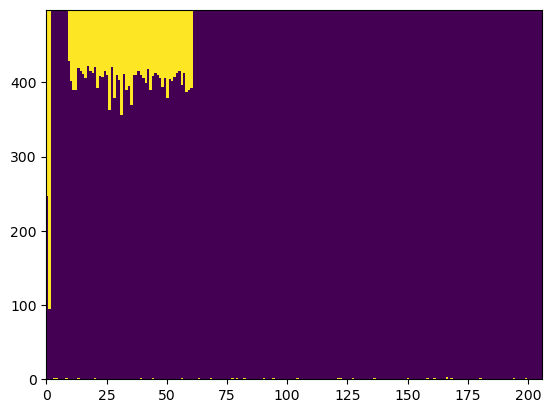

In [7]:
# Plot land
land = np.isnan(T)
plt.pcolor(land)
grS.shape

In [10]:
#TEOS 10
Lon2d = np.tile(lon_float, (depth1d.size,1))
Lat2d = np.tile(lat_float, (depth1d.size,1))
print(salinity.shape)
SA = gsw.SA_from_SP(salinity,pres_float,Lon2d,Lat2d)
CT = gsw.CT_from_pt(SA,theta)
sigma0 = gsw.sigma0(SA, CT)+1000.
sp = gsw.spiciness0(SA,CT)

(498, 206)


In [11]:
gamman0 = np.copy(gamman)
#gamman = neutral-1000

In [12]:
# Converts the datevec to time format
dates = pd.to_datetime({
    'year': time[:, 0],
    'month': time[:, 1],
    'day': time[:, 2],
    'hour': time[:, 3],
    'minute': time[:, 4],
    'second': time[:, 5]
})

## make section plot

Text(0.5, 1.0, '$\\chi_{\\theta}$ (K$^2$/s)')

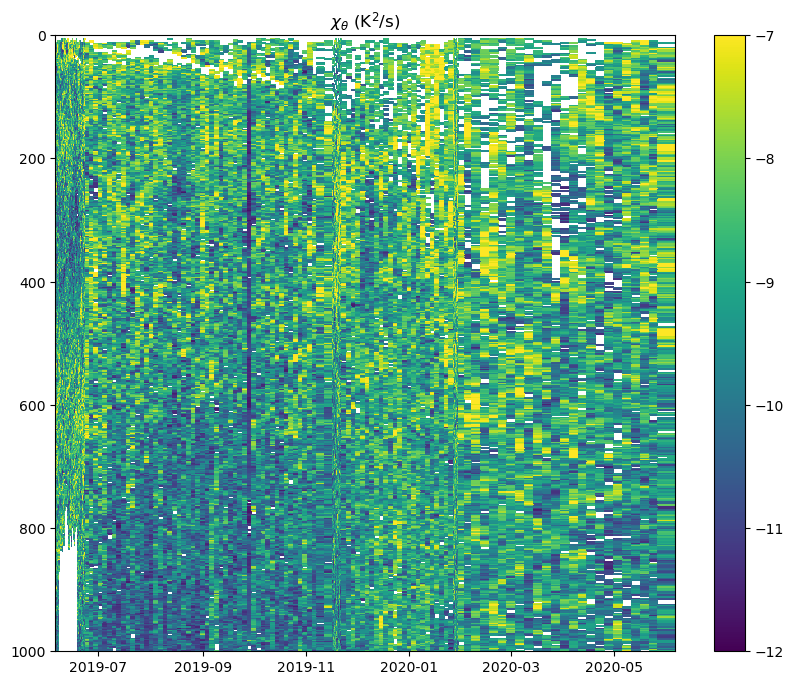

In [14]:
# Single plot with pcolor
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Create pcolor plot
cc = ax.pcolor(dates, pres_float, np.log10(chi), 
               vmin=-12, vmax=-7, shading='auto')
plt.colorbar(cc, ax = ax)
ax.set_ylim((1000,0))
ax.set_title("$\\chi_{\\theta}$ (K$^2$/s)")

# Sorts the density profiles (from low density to high density to remove overturns)

In [15]:
"""

gamman_s = np.full(theta.shape, np.nan)
theta_s = np.full(theta.shape, np.nan)
salinity_s = np.full(salinity.shape, np.nan)
for i in range(lon_float.size):
    sg0 = gamman[:,i]
    iif = np.isfinite(sg0)
    gamman_s[iif,i] = np.sort(gamman[iif,i])
    iis = np.argsort(gamman[iif,i])
    theta_s[iif,i] =theta[iif,i][iis]
    salinity_s[iif,i] = salinity[iif,i][iis]
    
"""

'\n\ngamman_s = np.full(theta.shape, np.nan)\ntheta_s = np.full(theta.shape, np.nan)\nsalinity_s = np.full(salinity.shape, np.nan)\nfor i in range(lon_float.size):\n    sg0 = gamman[:,i]\n    iif = np.isfinite(sg0)\n    gamman_s[iif,i] = np.sort(gamman[iif,i])\n    iis = np.argsort(gamman[iif,i])\n    theta_s[iif,i] =theta[iif,i][iis]\n    salinity_s[iif,i] = salinity[iif,i][iis]\n\n'

# Builds the smooth "mean flow" temperature and salinity profiles

In [16]:
"""

import warnings

# Universal polyfit warning suppression
warnings.filterwarnings('ignore', 
                       message='.*[Pp]olyfit.*poorly conditioned.*')
# Now all polyfit warnings will be suppressed in the entire notebook


h = 400 #defines the segment length
theta_mean = np.full(theta.shape, np.nan)
salinity_mean = np.full(theta.shape, np.nan)
oxygen_mean = np.full(theta.shape, np.nan)
for i in range(lon_vmp.size):
    #print(i)
    #sg_smooth = moving_average(gamman_s[:,i],10)
    for j in range(pres_vmp.size):
        deepest = np.where(np.isfinite(theta[:,i]))[0][-1]
        deepest_pres = pres_vmp[deepest]
        min_pres = pres_vmp[j]-h/2
        max_pres = pres_vmp[j]+h/2
        if min_pres<0:
            
            max_pres+=np.abs(min_pres)
            min_pres= 0
        if max_pres>deepest_pres:
            delta = max_pres-deepest_pres
            min_pres-=delta
            max_pres = np.copy(deepest_pres)
            
        jj = np.where( (pres_vmp>=min_pres) & (pres_vmp<=max_pres) & (np.isfinite(gamman_s[:,i])))[0]
        
        pt = np.polyfit(gamman_s[jj,i],theta_s[jj,i],4)
        ppt = np.poly1d(pt)
        theta_mean[j,i] = ppt(gamman_s[j,i])

        
        ps = np.polyfit(gamman_s[jj,i],salinity_s[jj,i],4)
        pps = np.poly1d(ps)
        salinity_mean[j,i] = pps(gamman_s[j,i])
        
        po = np.polyfit(gamman_s[jj,i],oxygen_s[jj,i],4)
        ppo = np.poly1d(po)
        oxygen_mean[j,i] = ppo(gamman_s[j,i])
        

"""      

"\n\nimport warnings\n\n# Universal polyfit warning suppression\nwarnings.filterwarnings('ignore', \n                       message='.*[Pp]olyfit.*poorly conditioned.*')\n# Now all polyfit warnings will be suppressed in the entire notebook\n\n\nh = 400 #defines the segment length\ntheta_mean = np.full(theta.shape, np.nan)\nsalinity_mean = np.full(theta.shape, np.nan)\noxygen_mean = np.full(theta.shape, np.nan)\nfor i in range(lon_vmp.size):\n    #print(i)\n    #sg_smooth = moving_average(gamman_s[:,i],10)\n    for j in range(pres_vmp.size):\n        deepest = np.where(np.isfinite(theta[:,i]))[0][-1]\n        deepest_pres = pres_vmp[deepest]\n        min_pres = pres_vmp[j]-h/2\n        max_pres = pres_vmp[j]+h/2\n        if min_pres<0:\n\n            max_pres+=np.abs(min_pres)\n            min_pres= 0\n        if max_pres>deepest_pres:\n            delta = max_pres-deepest_pres\n            min_pres-=delta\n            max_pres = np.copy(deepest_pres)\n\n        jj = np.where( (pres_vmp

# Calculates the "mean flow" temperature, salinity gradients and N2

In [ ]:
"""

grT_mean = np.full(theta.shape, np.nan)
grS_mean = np.full(theta.shape, np.nan)
grO_mean = np.full(theta.shape, np.nan)
N2 = np.full(theta.shape, np.nan)
for i in range(lon_vmp.size):
    
    for j in range(1,pres_vmp.size-1):
        grT_mean[j,i] = -(theta_mean[j+1,i] - theta_mean[j-1,i])/(depth[j+1,i] - depth[j-1,i])
        grS_mean[j,i] = -(salinity_mean[j+1,i] - salinity_mean[j-1,i])/(depth[j+1,i] - depth[j-1,i])
        grO_mean[j,i] = -(oxygen_mean[j+1,i] - oxygen_mean[j-1,i])/(depth[j+1,i] - depth[j-1,i])
        
        N2[j,i] = 9.81/1027*(gamman_s[j+1,i] -gamman_s[j-1,i])/(depth[j+1,i] - depth[j-1,i])

N2[N2<1e-8] = np.nan #removes very low N2 in the bottom boundary layer, which pose problems

"""

# Caculates terms of the salinity and temperature variance budget

In [17]:
"""

Krho = 0.2*epsilon/N2 #diapycnal diffusivity

chi_dia = 2*Krho*grT**2 #diapycnal production of thermal variance including fine scale: should be similar to chi

Pdia=  2*Krho*grT_mean**2 #diapycnal production of thermal on the mean flow profile

chiS = 2*Krho*grS**2 #diapycnal production of haline variance including fine scale: should be similar to chi

PdiaS=  2*Krho*grS_mean**2  #diapycnal production of haline on the mean flow profile

chiS[chiS>1e-4] = np.nan #removes some outlier

chiO = 2*Krho*grO**2 #diapycnal production of haline variance including fine scale: should be similar to chi

PdiaO=  2*Krho*grO_mean**2  #diapycnal production of haline on the mean flow profile

"""

_IncompleteInputError: incomplete input (2502771238.py, line 1)

## tests that local diapycnal production roughly balances chi (like figure 2 in my paper)

In [ ]:
"""

import cmocean 

dchi = 0.25
xchi = np.arange(-14.5,-1.5,dchi)
hist_chis = np.full((xchi.size, xchi.size), 0)
hist_chi_dia = np.full((xchi.size, xchi.size), 0)

for i in range(xchi.size):
    ii0 = (np.abs( np.log10(chi_dia)-xchi[i] )<dchi/2)
    hist_chi_dia[i] = np.sum(ii0)
    for j in range(xchi.size):
        ii = (np.abs( np.log10(chi)-xchi[i] )<dchi/2) & (np.abs( np.log10(chi_dia)-xchi[j] )<dchi/2)
        hist_chis[i,j] = np.sum(ii )

fig, ax = plt.subplots()
#ax.loglog(chi.ravel(), chi_dia0.ravel(),'.')
cc=ax.contourf(xchi,xchi, hist_chis,50, cmap  = cmocean.cm.rain)
cb = plt.colorbar(cc)
#cb.set_ticks(np.arange(0,4,1))
#cb.set_ticklabels( 10**np.arange(0,4,1))
ax.plot([-14,-3],[-14,-3],color = "k")
ax.plot([-14,-3],[-14+np.log10(10),-3+np.log10(10)],color = "k", ls = "dotted",lw = 1)
ax.plot([-14,-3],[-14-np.log10(10),-3-np.log10(10)],color = "k", ls = "dotted",lw = 1)
ax.plot([-14,-3],[-14+np.log10(2),-3+np.log10(2)],color = "k", ls = "--",lw = 1)
ax.plot([-14,-3],[-14-np.log10(2),-3-np.log10(2)],color = "k", ls = "--",lw = 1)

ax.annotate("10:1", xy = (-7,-6), ha = "center", va = "bottom", rotation = 45, fontsize = 8)
ax.annotate("2:1", xy = (np.log10(2e-7),np.log10(4e-7)), ha = "center", va = "bottom", rotation = 45, fontsize = 8)

ax.annotate("1:10", xy = (np.log10(1.2e-6),np.log10(1.2e-7)), ha = "center", va = "top", rotation = 45, fontsize = 8)
ax.annotate("1:2", xy = (np.log10(6e-7),np.log10(3e-7)), ha = "center", va = "top", rotation = 45, fontsize = 8)

ax.set_xlim((-14,-5))
ax.set_ylim((-14,-5))
ax.set_xticks(np.arange(-14,-4))
ax.set_xticklabels(["$10^{%s}$"%(x) for x in range(-14,-4)])
ax.set_yticks(np.arange(-14,-4))
ax.set_yticklabels(["$10^{%s}$"%(x) for x in range(-14,-4)])
ax.set_xlabel(" $ P_{\\theta^2} = 2 K_{\\rho} (\partial _{z} \\overline{\\theta})^2$ (K$^2$/s)")
ax.set_ylabel(" $\\chi_{\\theta}$ (K$^2$/s)")
ax.grid(True)

figname=["RREX2017_Ridge_chi_vs_localP.png","RREX2017_XRidge_chi_vs_localP.png","RREX2017_WRidge_chi_vs_localP.png"]
#fig.savefig(figname[location], dpi =300, bbox_inches = "tight")

fig, ax = plt.subplots(1)
ax.plot(xchi, np.sum(hist_chis, axis = 1))
ax.plot(xchi, np.sum(hist_chis, axis = 0))

"""

# Makes some plots 

In [ ]:
"""

Pdia_m=moving_average(np.nanmean(Pdia[:,:], axis =1),30,window = "gauss")
PdiaS_m=moving_average(np.nanmean(PdiaS[:,:], axis =1),30,window = "gauss")
PdiaO_m=moving_average(np.nanmean(PdiaO[:,:], axis =1),30,window = "gauss")
chi_m=moving_average(np.nanmean(chi[:,:], axis =1),30,window = "gauss")
chi_dia_m=moving_average(np.nanmean(chi_dia[:,:], axis =1),30,window = "gauss")
chiS_m=moving_average(np.nanmean(chiS[:,:], axis =1),30,window = "gauss")
chiO_m=moving_average(np.nanmean(chiO[:,:], axis =1),30,window = "gauss")

dia_theta_percent=(np.nanmean(Pdia_m/chi_m))*100
dia_theta_percent=np.round(dia_theta_percent,decimals=1)

dia_S_percent=(np.nanmean(PdiaS_m/chiS_m))*100
dia_S_percent=np.round(dia_S_percent,decimals=1)

dia_O_percent=(np.nanmean(PdiaO_m/chiO_m))*100
dia_O_percent=np.round(dia_O_percent,decimals=1)

"""

In [ ]:
"""

fig, ax = plt.subplots(1,3, sharey = True, figsize = (12,5))


ax[0].semilogx(Pdia_m, pres_vmp,label ="$P_{\\theta}^{\\perp}$")
ax[0].semilogx(chi_dia_m, pres_vmp, color = "gray", label ="$P_{\\theta}$" )
ax[0].semilogx(chi_m,  pres_vmp, color = "k", label = "$\chi_{\\theta}$")
ax[0].set_ylim((4000,0))
ax[0].set_xlim((5e-12,1e-6))
ax[0].legend()
ax[0].set_ylabel("Pressure (dbar)")
ax[0].set_title("Thermal variance budget")
ax[0].set_xlabel("K$^2$/s")
ax[0].grid(True)
ax[0].text(8e-9, 3000, '$P_{\\theta}^{\\perp}/\chi$ =' + f'{dia_theta_percent}%', 
           fontsize=10,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax[1].semilogx(PdiaS_m, pres_vmp,label ="$P_S^{\\perp}$")
ax[1].semilogx(chiS_m, pres_vmp, color = "gray", label = "$P_S \\approx \chi_S$")
ax[1].legend()
ax[1].set_title("Haline variance budget")
ax[1].set_xlabel("PSU$^2$/s")
ax[1].grid(True)
ax[1].set_ylim((4000,0))
ax[1].set_xlim((1e-14,1e-6))
ax[1].text(8e-10, 3000, '$P_S^{\\perp}/\chi_S$ =' + f'{dia_S_percent}%', 
           fontsize=10,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax[2].semilogx(PdiaO_m, pres_vmp,label ="$P_O^{\\perp}$")
ax[2].semilogx(chiO_m, pres_vmp, color = "gray", label = "$P_O \\approx \chi_O$")
ax[2].legend()
ax[2].set_title("Oxygen variance budget")
ax[2].set_xlabel("(umol/kg))$^2$/s")
ax[2].grid(True)
ax[2].set_ylim((4000,0))
ax[2].set_xlim((1e-10,1e-4))
ax[2].text(5e-7, 3000, '$P_O^{\\perp}/\chi_O$ =' + f'{dia_O_percent}%', 
           fontsize=10,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

figtitle=['Diapycnal/Total Variance Analysis of RREX2017 - Reykjanes Ridge',
          'Diapycnal/Total Variance Analysis of RREX2017 - Across the Ridge',
          'Diapycnal/Total Variance Analysis of RREX2017 - West of Ridge']
          
plt.suptitle(figtitle[location],fontsize=12,fontweight='bold')

figname=['RREX2017_Ridge_VarianceBudget_Merged.png',
         'RREX2017_XRidge_VarianceBudget_Merged.png',
         'RREX2017_WRidge_VarianceBudget_Merged.png']

#plt.savefig(figname[location]) 

"""

# Caculates terms of the salinity and temperature variance budget but using Kp derived from Osborn

In [18]:
# Calculate the _mean profiles in pressure coordinates instead of density ones
theta_mean_oz = np.full(theta.shape, np.nan)
salinity_mean_oz = np.full(theta.shape, np.nan)

# Low pass method
n=75 # Window ~ 300 meters
for i in range(lon_float.size):
    theta_mean_oz[:,i]=moving_average(theta[:,i],n,window = "gauss")
    salinity_mean_oz[:,i]=moving_average(salinity[:,i],n,window = "gauss")


grT_mean_oz = np.full(theta.shape, np.nan)
grS_mean_oz = np.full(theta.shape, np.nan)
for i in range(lon_float.size):
    
    for j in range(1,depth1d.size-1):
        grT_mean_oz[j,i] = -(theta_mean_oz[j+1,i] - theta_mean_oz[j-1,i])/(depth1d[j+1] - depth1d[j-1])
        grS_mean_oz[j,i] = -(salinity_mean_oz[j+1,i] - salinity_mean_oz[j-1,i])/(depth1d[j+1] - depth1d[j-1])



/tmp/ipykernel_7475/3305096613.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grT_mean_oz[j,i] = -(theta_mean_oz[j+1,i] - theta_mean_oz[j-1,i])/(depth1d[j+1] - depth1d[j-1])
/tmp/ipykernel_7475/3305096613.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grS_mean_oz[j,i] = -(salinity_mean_oz[j+1,i] - salinity_mean_oz[j-1,i])/(depth1d[j+1] - depth1d[j-1])


In [19]:
# The same but deriving Krho using Osborn

chi_oz = np.full(chi.shape, np.nan)
grT2_oz = np.full(chi.shape, np.nan)
grT2=grT**2

n=15 # Window ~ 60 meters
for i in range(lon_float.size):
    chi_oz[:,i]=moving_average(chi[:,i],n,window = "gauss")
    grT2_oz[:,i]=moving_average(grT2[:,i],n,window = "gauss")

Krho_oz = chi_oz/(2*grT2_oz) #diapycnal diffusivity

chi_dia_oz = 2*Krho_oz*grT2 #diapycnal production of thermal variance including fine scale: should be similar to chi

Pdia_oz=  2*Krho_oz*grT_mean_oz**2 #diapycnal production of thermal on the mean flow profile

chiS_oz = 2*Krho_oz*grS**2 #diapycnal production of haline variance including fine scale: should be similar to chi

PdiaS_oz=  2*Krho_oz*grS_mean_oz**2  #diapycnal production of haline on the mean flow profile

chiS_oz[chiS_oz>1e-4] = np.nan #removes some outlier

<>:37: SyntaxWarning: invalid escape sequence '\p'
<>:37: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_7475/3654810237.py:37: SyntaxWarning: invalid escape sequence '\p'
  ax.set_xlabel(" $ P_{\\theta^2_{Os}} = 2 K_{\\rho} (\partial _{z} \\overline{\\theta})^2$ (K$^2$/s)")


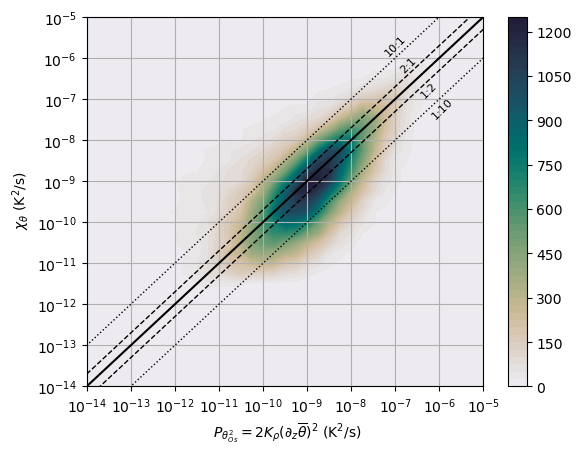

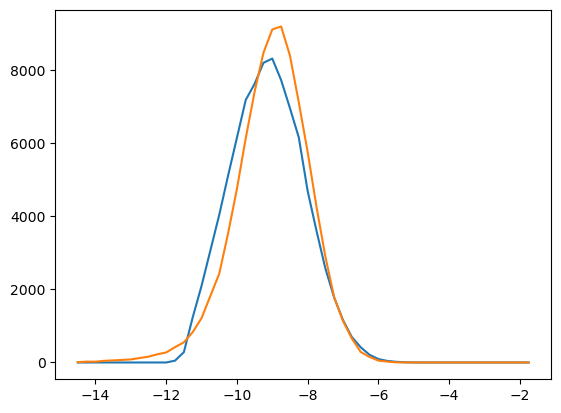

In [20]:
dchi = 0.25
xchi = np.arange(-14.5,-1.5,dchi)
hist_chis = np.full((xchi.size, xchi.size), 0)
hist_chi_dia = np.full((xchi.size, xchi.size), 0)

for i in range(xchi.size):
    ii0 = (np.abs( np.log10(chi_dia_oz)-xchi[i] )<dchi/2)
    hist_chi_dia[i] = np.sum(ii0)
    for j in range(xchi.size):
        ii = (np.abs( np.log10(chi)-xchi[i] )<dchi/2) & (np.abs( np.log10(chi_dia_oz)-xchi[j] )<dchi/2)
        hist_chis[i,j] = np.sum(ii )

fig, ax = plt.subplots()
#ax.loglog(chi.ravel(), chi_dia0.ravel(),'.')
cc=ax.contourf(xchi,xchi, hist_chis,50, cmap  = cmocean.cm.rain)
cb = plt.colorbar(cc)
#cb.set_ticks(np.arange(0,4,1))
#cb.set_ticklabels( 10**np.arange(0,4,1))
ax.plot([-14,-3],[-14,-3],color = "k")
ax.plot([-14,-3],[-14+np.log10(10),-3+np.log10(10)],color = "k", ls = "dotted",lw = 1)
ax.plot([-14,-3],[-14-np.log10(10),-3-np.log10(10)],color = "k", ls = "dotted",lw = 1)
ax.plot([-14,-3],[-14+np.log10(2),-3+np.log10(2)],color = "k", ls = "--",lw = 1)
ax.plot([-14,-3],[-14-np.log10(2),-3-np.log10(2)],color = "k", ls = "--",lw = 1)

ax.annotate("10:1", xy = (-7,-6), ha = "center", va = "bottom", rotation = 45, fontsize = 8)
ax.annotate("2:1", xy = (np.log10(2e-7),np.log10(4e-7)), ha = "center", va = "bottom", rotation = 45, fontsize = 8)

ax.annotate("1:10", xy = (np.log10(1.2e-6),np.log10(1.2e-7)), ha = "center", va = "top", rotation = 45, fontsize = 8)
ax.annotate("1:2", xy = (np.log10(6e-7),np.log10(3e-7)), ha = "center", va = "top", rotation = 45, fontsize = 8)

ax.set_xlim((-14,-5))
ax.set_ylim((-14,-5))
ax.set_xticks(np.arange(-14,-4))
ax.set_xticklabels(["$10^{%s}$"%(x) for x in range(-14,-4)])
ax.set_yticks(np.arange(-14,-4))
ax.set_yticklabels(["$10^{%s}$"%(x) for x in range(-14,-4)])
ax.set_xlabel(" $ P_{\\theta^2_{Os}} = 2 K_{\\rho} (\partial _{z} \\overline{\\theta})^2$ (K$^2$/s)")
ax.set_ylabel(" $\\chi_{\\theta}$ (K$^2$/s)")
ax.grid(True)

figname=["RREX2017_Ridge_Os_chi_vs_localP.png",
         "RREX2017_XRidge_Os_chi_vs_localP.png",
         "RREX2017_WRidge_Os_chi_vs_localP.png"]

#fig.savefig(figname[location], dpi =300, bbox_inches = "tight")

fig, ax = plt.subplots(1)
ax.plot(xchi, np.sum(hist_chis, axis = 1))
ax.plot(xchi, np.sum(hist_chis, axis = 0))

In [21]:
Pdia_oz_m=moving_average(np.nanmean(Pdia_oz[:,:], axis =1),30,window = "gauss")
PdiaS_oz_m=moving_average(np.nanmean(PdiaS_oz[:,:], axis =1),30,window = "gauss")
chi_oz_m=moving_average(np.nanmean(chi_oz[:,:], axis =1),30,window = "gauss")
chi_dia_oz_m=moving_average(np.nanmean(chi_dia_oz[:,:], axis =1),30,window = "gauss")
chiS_oz_m=moving_average(np.nanmean(chiS_oz[:,:], axis =1),30,window = "gauss")

dia_theta_oz_percent=(np.nanmean(Pdia_oz_m/chi_oz_m))*100
dia_theta_oz_percent=np.round(dia_theta_oz_percent,decimals=1)

dia_S_oz_percent=(np.nanmean(PdiaS_oz_m/chiS_oz_m))*100
dia_S_oz_percent=np.round(dia_S_oz_percent,decimals=1)

/tmp/ipykernel_7475/3156361673.py:1: RuntimeWarning: Mean of empty slice
  Pdia_oz_m=moving_average(np.nanmean(Pdia_oz[:,:], axis =1),30,window = "gauss")
/tmp/ipykernel_7475/3156361673.py:2: RuntimeWarning: Mean of empty slice
  PdiaS_oz_m=moving_average(np.nanmean(PdiaS_oz[:,:], axis =1),30,window = "gauss")
/tmp/ipykernel_7475/3156361673.py:4: RuntimeWarning: Mean of empty slice
  chi_dia_oz_m=moving_average(np.nanmean(chi_dia_oz[:,:], axis =1),30,window = "gauss")
/tmp/ipykernel_7475/3156361673.py:5: RuntimeWarning: Mean of empty slice
  chiS_oz_m=moving_average(np.nanmean(chiS_oz[:,:], axis =1),30,window = "gauss")


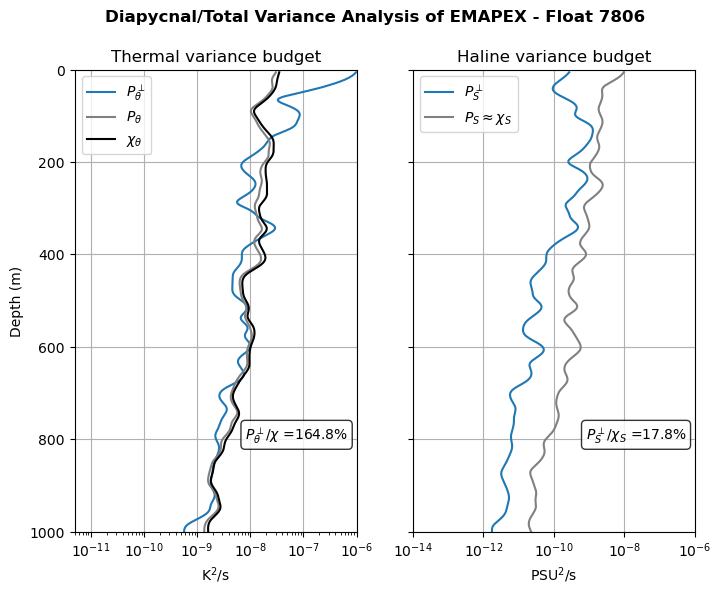

In [42]:
# Also using Osborn Krho
fig, ax = plt.subplots(1,2, sharey = True, figsize = (8,6))

ax[0].semilogx(Pdia_oz_m, -depth1d,label ="$P_{\\theta}^{\\perp}$")
ax[0].semilogx(chi_dia_oz_m, -depth1d, color = "gray", label ="$P_{\\theta}$" )
ax[0].semilogx(chi_oz_m,  -depth1d, color = "k", label = "$\\chi_{\\theta}$")
ax[0].set_ylim((1000,0))
ax[0].set_xlim((5e-12,1e-6))
ax[0].legend()
ax[0].set_ylabel("Depth (m)")
ax[0].set_title("Thermal variance budget")
ax[0].set_xlabel("K$^2$/s")
ax[0].grid(True)
ax[0].text(8e-9, 800, '$P_{\\theta}^{\\perp}/\\chi$ =' + f'{dia_theta_oz_percent}%', 
           fontsize=10,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax[1].semilogx(PdiaS_oz_m, -depth1d,label ="$P_S^{\\perp}$")
ax[1].semilogx(chiS_oz_m, -depth1d, color = "gray", label = "$P_S \\approx \\chi_S$")
ax[1].legend()
ax[1].set_title("Haline variance budget")
ax[1].set_xlabel("PSU$^2$/s")
ax[1].grid(True)
ax[1].set_ylim((1000,0))
ax[1].set_xlim((1e-14,1e-6))
ax[1].text(8e-10, 800, '$P_S^{\\perp}/\\chi_S$ =' + f'{dia_S_oz_percent}%', 
           fontsize=10,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


figtitle=['Diapycnal/Total Variance Analysis of EMAPEX - Float 7806']

plt.suptitle(figtitle[location],fontsize=12,fontweight='bold')

figname=['4_EMAPEX_Float7806_VarianceBudget.png']

plt.savefig(figname[location]) 

In [ ]:
# Comparison between both methods for deriving Kp

fig, ax = plt.subplots(1,2, sharey = True, figsize = (10,5))


ax[0].semilogx(Pdia_m, pres_vmp, color = "b",label ="$P_{\\theta}^{\\perp}$")
ax[0].semilogx(Pdia_oz_m, pres_vmp, color = "k",label ="$P_{\\theta_{OC}}^{\\perp}$")
ax[0].set_ylim((4000,0))
ax[0].set_xlim((5e-12,1e-6))
ax[0].legend()
ax[0].set_ylabel("Pressure (dbar)")
#ax[0].set_title("Thermal variance budget")
ax[0].set_xlabel("K$^2$/s")
ax[0].grid(True)
#ax[0].text(8e-9, 3000, '$P_{\\theta}^{\\perp}/\chi$ =' + f'{dia_theta_oz_percent}%', 
#           fontsize=10,
#           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax[1].semilogx(chi_dia_m, pres_vmp, color = "blue", label ="$P_{\\theta}$" )
ax[1].semilogx(chi_dia_oz_m, pres_vmp, color = "black", label ="$P_{\\theta_{OC}}$" )
ax[1].semilogx(chi_m,  pres_vmp, color = "r", label = "$\chi_{\\theta}$")
ax[1].legend()
#ax[1].set_title("Haline variance budget")
ax[1].set_xlabel("K$^2$/s")
ax[1].grid(True)
ax[1].set_ylim((4000,0))
ax[1].set_xlim((1e-14,1e-6))


figtitle=['Comparison of $\chi_{\\theta}$ methods - RREX2017 - Along-Ridge',
          'Comparison of $\chi_{\\theta}$ methods - RREX2017 - Cross-Ridge',
          'Comparison of $\chi_{\\theta}$ methods - RREX2017 - West of Ridge']

plt.suptitle(figtitle[location],fontsize=12,fontweight='bold')

figname=['RREX2017_Ridge_VarianceMethodComparison.png',
         'RREX2017_XRidge_VarianceMethodComparison.png',
         'RREX2017_WRidge_VarianceMethodComparison.png']

#plt.savefig(figname[location]) 

In [ ]:
fig, ax = plt.subplots(1,3, sharey = True, figsize = (12,5))

# Compare vertical gradients

ax[0].plot(np.nanmean(grT_mean,axis=1), pres_vmp, color = "b",label ="${\\nabla_{\\rho}}{\\theta}$")
ax[0].plot(np.nanmean(grT_mean_oz,axis=1), pres_vmp, color = "k",label ="${\\nabla_{z}}{\\theta}$")
ax[0].set_ylim((4000,0))
ax[0].set_xlim((-0.005,0.025))
ax[0].legend()
ax[0].set_ylabel("Pressure (dbar)")
#ax[0].set_title("Thermal variance budget")
ax[0].set_xlabel("C/s")
ax[0].grid(True)
#ax[0].text(8e-9, 3000, '$P_{\\theta}^{\\perp}/\chi$ =' + f'{dia_theta_oz_percent}%', 
#           fontsize=10,
#           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax[1].plot(np.nanmean(grS_mean,axis=1), pres_vmp, color = "b",label ="${\\nabla_{\\rho}}{S}$")
ax[1].plot(np.nanmean(grS_mean_oz,axis=1), pres_vmp, color = "k",label ="${\\nabla_{z}}{S}$")
ax[1].legend()
#ax[1].set_title("Haline variance budget")
ax[1].set_xlabel("PSU/m")
ax[1].grid(True)
ax[1].set_ylim((4000,0))
#ax[1].set_xlim((1e-14,1e-6))


ax[2].plot(np.nanmean(grO_mean,axis=1), pres_vmp, color = "b",label ="${\\nabla_{\\rho}}{O}$")
ax[2].plot(np.nanmean(grO_mean_oz,axis=1), pres_vmp, color = "k",label ="${\\nabla_{z}}{O}$")
ax[2].legend()
#ax[2].set_title("Oxygen variance budget")
ax[2].set_xlabel("(umol/kg)/m")
ax[2].grid(True)
ax[2].set_ylim((4000,0))
#ax[2].set_xlim((1e-10,1e-4))

figtitle=['Gradients - RREX2017 - Along-Ridge',
          'Gradients - RREX2017 - Cross-Ridge',
          'Gradients - RREX2017 - West of Ridge']

plt.suptitle(figtitle[location],fontsize=12,fontweight='bold')


figname=['RREX2017_Ridge_Gradients.png',
         'RREX2017_XRidge_Gradients.png',
         'RREX2017_WRidge_Gradients.png']

#plt.savefig(figname[location]) 
